In [9]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

In [25]:
data_dir = "data"

prices_pattern = os.path.join(data_dir, "prices_*.csv")
trades_pattern = os.path.join(data_dir, "trades_*.csv")

price_files = sorted(glob.glob(prices_pattern))   # ensure consistent order
trade_files = sorted(glob.glob(trades_pattern))

def load_and_concat(file_list):
    dfs = []
    for i, f in enumerate(file_list):
        df = pd.read_csv(f, sep=";")
        
        # Apply timestamp offset
        if "timestamp" in df.columns:
            df["timestamp"] = df["timestamp"] + i * 1_000_000
        
        df["source_file"] = os.path.basename(f)
        dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

prices_df = load_and_concat(price_files)
trades_df = load_and_concat(trade_files)

In [26]:
emeralds = prices_df[prices_df['product'] == "EMERALDS"].copy()
emeralds.head(5)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,source_file
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0,prices_round_0_day_-1.csv
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0,prices_round_0_day_-1.csv
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0,prices_round_0_day_-1.csv
7,-1,300,EMERALDS,9992,11,9990,29,NaN,NaN,10008,11,10010,29,NaN,NaN,10000.0,0.0,prices_round_0_day_-1.csv
9,-1,400,EMERALDS,9992,12,9990,25,NaN,NaN,10008,12,10010,25,NaN,NaN,10000.0,0.0,prices_round_0_day_-1.csv


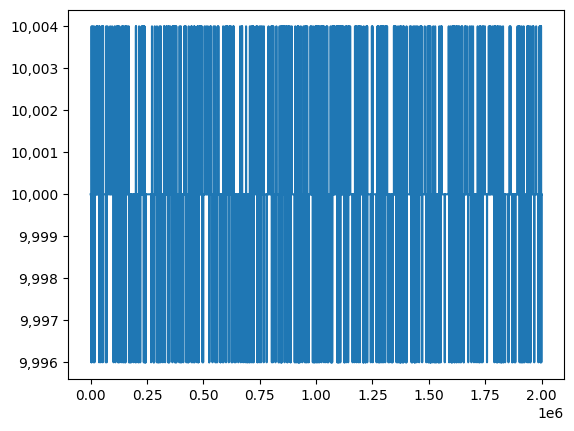

In [27]:
from matplotlib.ticker import FuncFormatter

plt.plot(emeralds['timestamp'], emeralds['mid_price'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()

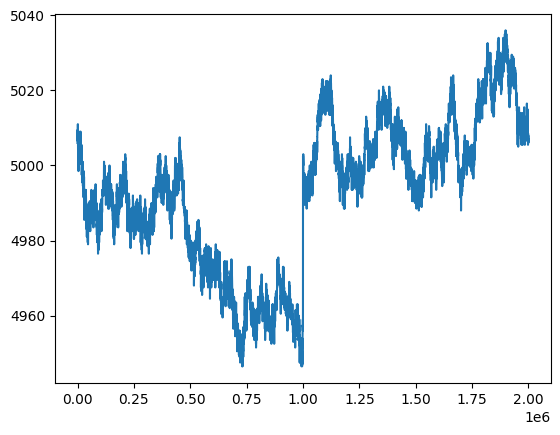

In [28]:
tomatoes = prices_df[prices_df['product'] == "TOMATOES"].copy()
plt.plot(tomatoes['timestamp'], tomatoes['mid_price'])
plt.show()